Oke, kita naikin levelnya jadi **lebih kompleks (mendekati real production thinking)** + sekalian aku jelasin **flow UI di Streamlit** biar jelas gimana kamu present ke user/recruiter.

Aku pakai case: **Customer Churn** (karena paling balance antara kompleks & visual)

---

# 📘 Day 1 — Customer Churn Prediction & Behavioral Intelligence

## 🧪 Dataset Problem Improvements (Advanced)

* Introduce temporal noise (fluktuasi usage per bulan)
* Simulate delayed labels (churn baru diketahui setelah beberapa waktu)
* Missing not at random (user churn → data usage hilang)
* Severe class imbalance (≤ 15% churn)
* Strong multicollinearity (tenure, total_charges, monthly_charges)
* Non-linear & interaction effects (usage × contract_type)
* Outliers (extreme spenders / inactive users)

---

# 🛠️ Tasks (Advanced Version)

## 🔍 1. Deep Exploratory Data Analysis

* Distribution per feature + segmented by churn
* Time-based behavior analysis (jika ada tenure progression)
* Outlier detection (IQR / z-score)
* Feature interaction visualization

---

## ❌ 2. Missing Data Strategy (lebih realistis)

* Detect missing patterns (MCAR / MAR / MNAR)
* Compare multiple imputations:

  * Mean/Median
  * KNN Imputation
* Evaluate impact ke model

---

## 🔗 3. Multicollinearity Handling

* Correlation heatmap
* Variance Inflation Factor (VIF)
* Drop vs retain + compare model performance

---

## ⚖️ 4. Imbalance Handling

* Compare:

  * No handling
  * Class weight
  * Oversampling (SMOTE)
* Evaluate impact ke F1-score

---

## ⚙️ 5. Feature Engineering (ini bikin keliatan advanced 🔥)

* tenure_group (new / mid / loyal)
* avg_monthly_usage
* charge_per_usage_ratio
* interaction features

---

## 📉 6. Dimensionality Reduction

* PCA (2D + 3D projection) pakai scikit-learn
* Compare sebelum vs sesudah scaling

---

## 🤖 7. Model Experimentation

* Logistic Regression (baseline)
* KNN (distance sensitivity)
* Random Forest (non-linear power)

---

## ⚙️ 8. Hyperparameter Optimization

* GridSearchCV
* Compare best params antar model

---

## 📊 9. Model Evaluation (lebih dalam)

* Accuracy (tidak cukup ⚠️)
* F1-score (utama)
* Precision / Recall tradeoff
* Confusion Matrix
* ROC Curve

---

## 🧠 10. Explainability

* Feature importance (Random Forest)
* Partial dependence (opsional advanced)
* Insight bisnis

---

## ❗ 11. Misclassification Analysis

* False Positive → user loyal tapi diprediksi churn
* False Negative → user churn tapi tidak terdeteksi
  👉 ini penting banget di dunia nyata

---

## 🔮 12. Prediction Simulation

* Input manual user → lihat probabilitas churn
* Sensitivity analysis (ubah 1 fitur → lihat perubahan output)

---

# 🎨 Streamlit App Structure (WAJIB jelas kalau mau portfolio kuat)

## 🧭 Sidebar Navigation

```
- Overview
- EDA
- Data Issues
- Feature Engineering
- Modeling
- Evaluation
- Insights
- Prediction Simulator
```

---

## 🖥️ 1. Overview Page

**Tujuan:** storytelling

Isi:

* Problem statement
* Dataset summary
* Class imbalance chart

---

## 📊 2. EDA Page

Visual:

* Histogram tiap fitur
* Boxplot vs churn
* Correlation heatmap (pakai Seaborn)

Interaktif:

* dropdown pilih fitur

---

## ⚠️ 3. Data Issues Page

Visual:

* Missing value heatmap
* Before vs after imputasi
* Outlier highlight

👉 ini bikin project kamu beda dari yang lain

---

## 🧪 4. Feature Engineering Page

Visual:

* Distribusi fitur baru
* Comparison feature lama vs baru

---

## 📉 5. PCA Visualization Page (🔥 core visual)

* Scatter plot 2D
* Warna = churn
* Toggle:

  * sebelum scaling
  * sesudah scaling

👉 pakai Plotly biar interaktif

---

## 🤖 6. Modeling Page

Interaktif:

* pilih model (LogReg / KNN / RF)
* adjust parameter (slider)

Output:

* training result
* decision boundary (di PCA space)

---

## 📊 7. Evaluation Page

Visual:

* Confusion matrix
* ROC curve
* Metric comparison chart

---

## 🧠 8. Insights Page

* Feature importance chart
* Top drivers churn
* Insight bisnis (bullet)

---

## 🎮 9. Prediction Simulator (🔥 ini killer feature)

User input:

* tenure
* monthly charges
* usage

Output:

* Probabilitas churn (%)
* Highlight faktor utama

---

# 💡 Kenapa ini kuat banget untuk portfolio?

Karena kamu menunjukkan:

* Data cleaning real-world
* Handling imbalance
* Multiple model comparison
* Explainability
* Interactive ML system

👉 ini sudah level **junior → mid data scientist**



In [128]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "WA_Fn-UseC_-Telco-Customer-Churn.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "blastchar/telco-customer-churn",
  file_path,
  # Provide any additional arguments like 
  # sql_query or pandas_kwargs. See the 
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

/tmp/ipykernel_123510/3690047211.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


First 5 records:    customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies    

In [129]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [130]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [131]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [132]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

# Preprocessing

## Menghapus variable yang tidak ada informasi

In [133]:
df.drop(columns=["customerID"], inplace=True)

## Handle categorial

In [134]:
categorical_columns = df.select_dtypes(include=['object']).columns
for col in categorical_columns:
    if(col != "TotalCharges"):
        print(f"Unique values in '{col}': {df[col].nunique()}")
        print(f"Value counts for '{col}':\n{df[col].value_counts()}\n")

Unique values in 'gender': 2
Value counts for 'gender':
gender
Male      3555
Female    3488
Name: count, dtype: int64

Unique values in 'Partner': 2
Value counts for 'Partner':
Partner
No     3641
Yes    3402
Name: count, dtype: int64

Unique values in 'Dependents': 2
Value counts for 'Dependents':
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

Unique values in 'PhoneService': 2
Value counts for 'PhoneService':
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

Unique values in 'MultipleLines': 3
Value counts for 'MultipleLines':
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

Unique values in 'InternetService': 3
Value counts for 'InternetService':
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

Unique values in 'OnlineSecurity': 3
Value counts for 'OnlineSecurity':
OnlineSecurity
No                     3498
Yes                    2019

/tmp/ipykernel_123510/504054515.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include=['object']).columns


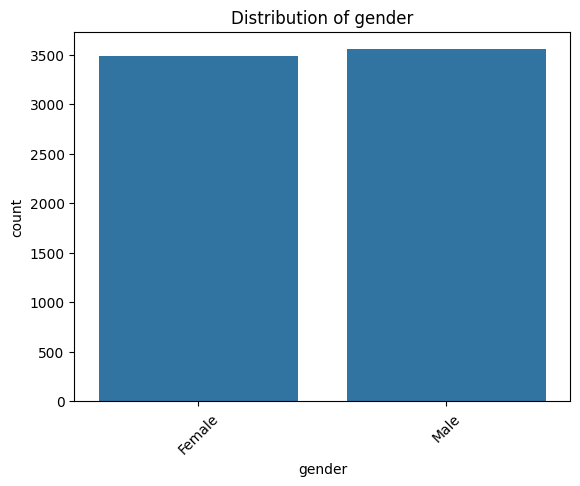

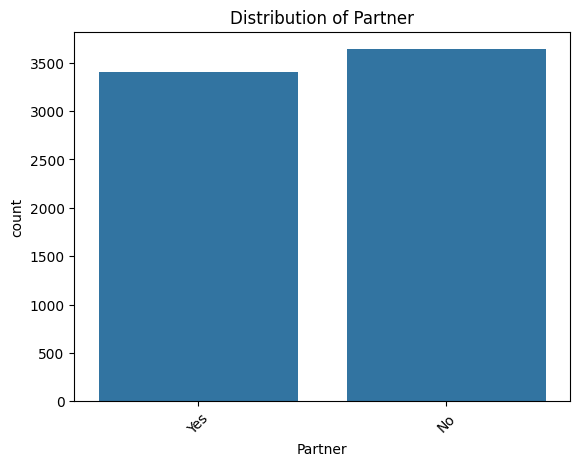

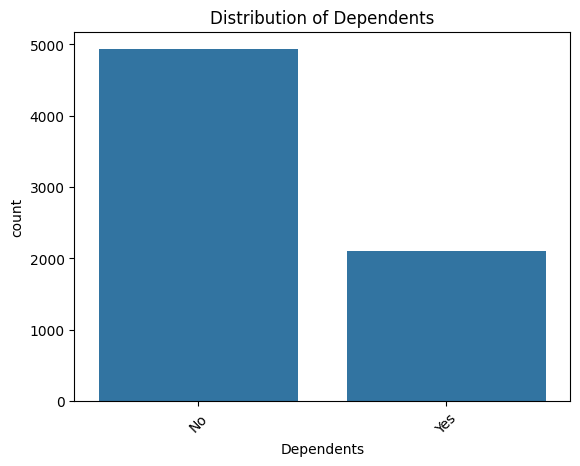

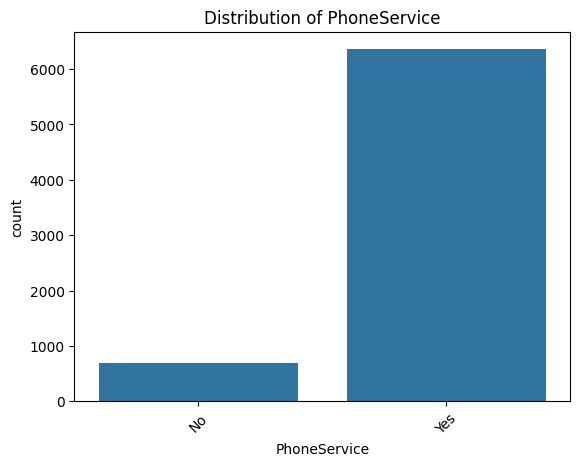

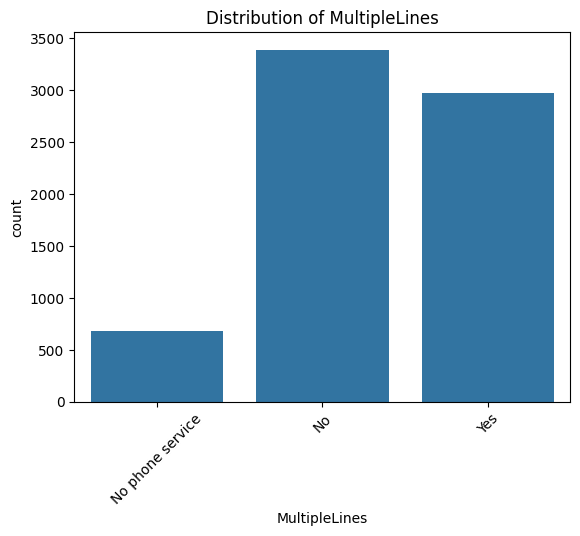

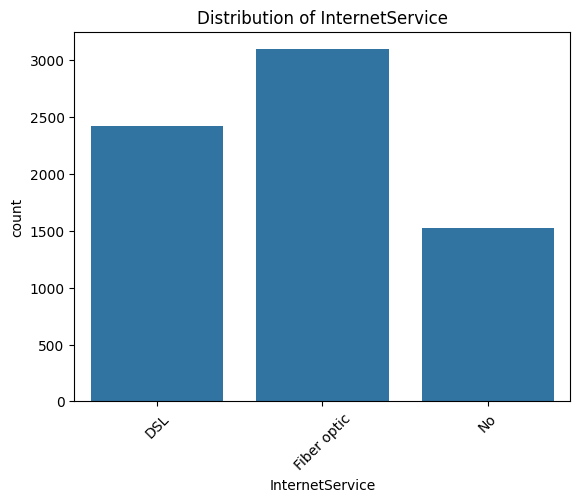

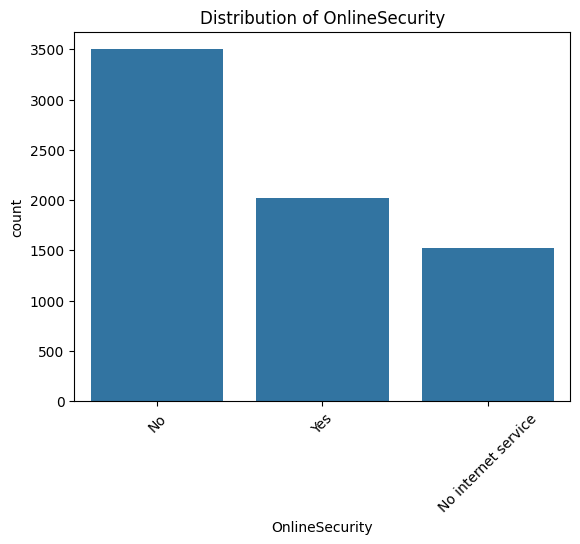

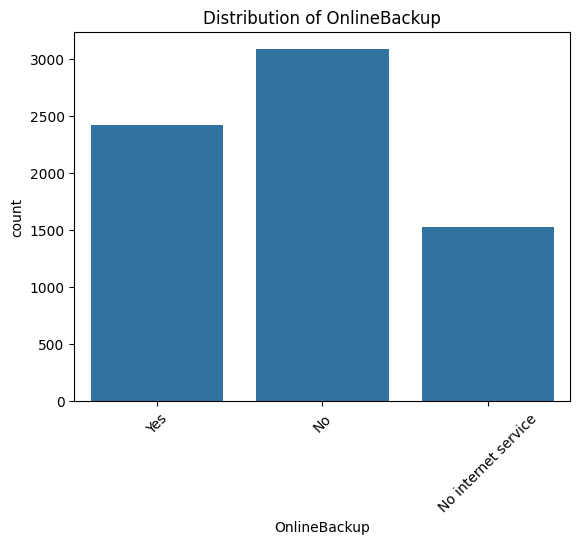

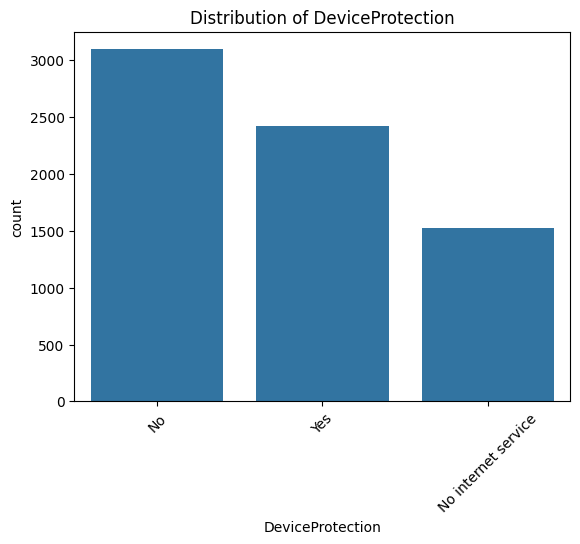

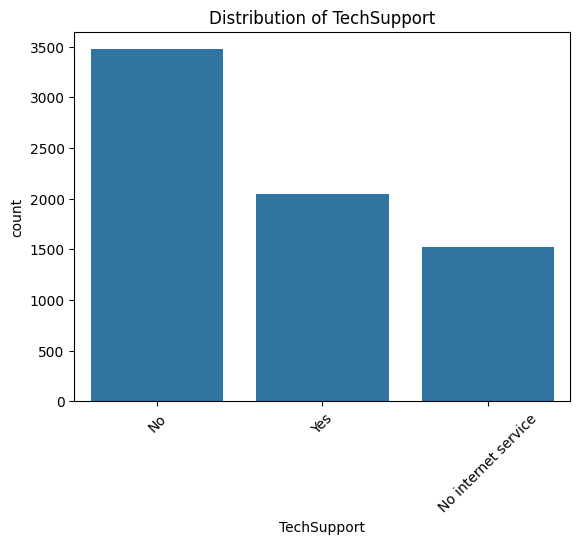

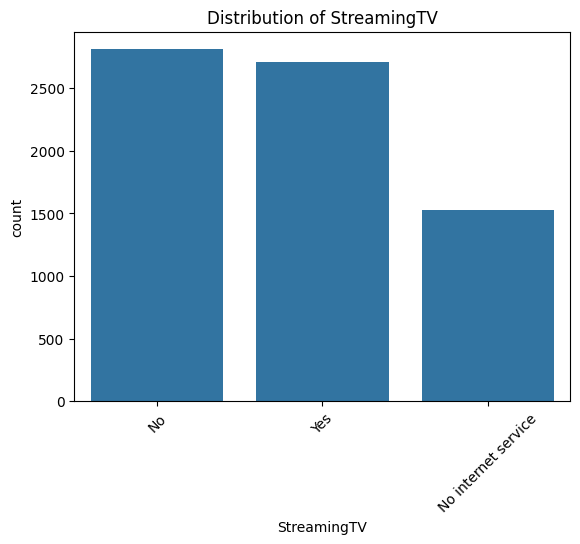

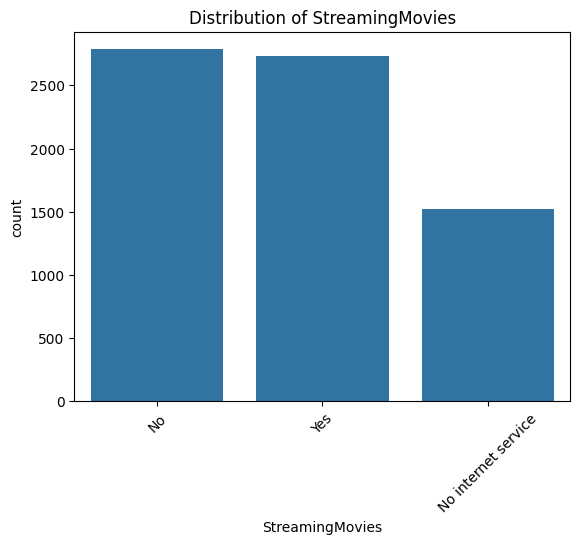

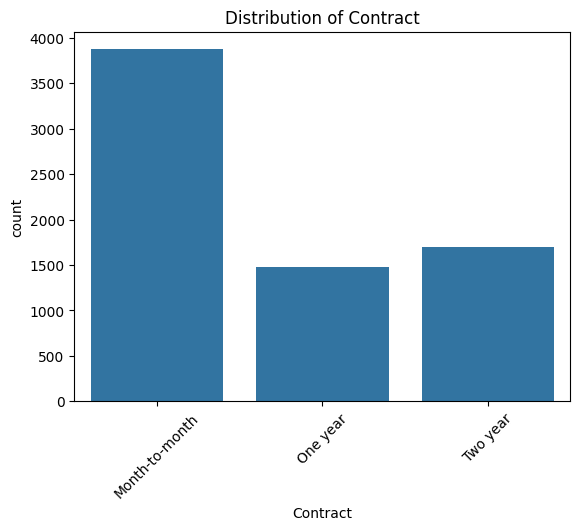

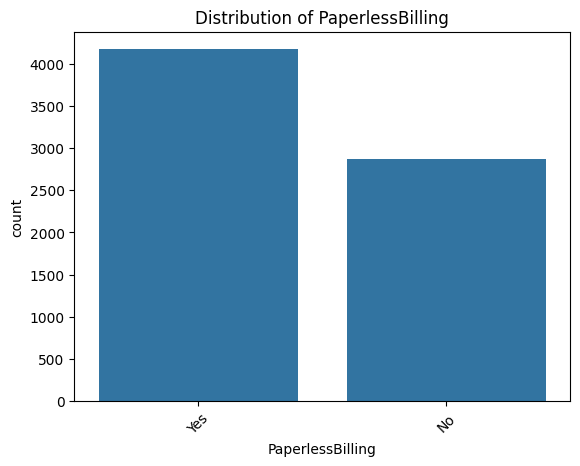

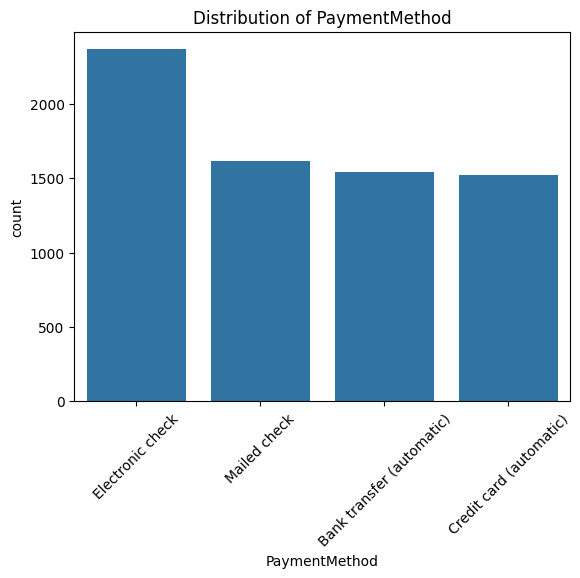

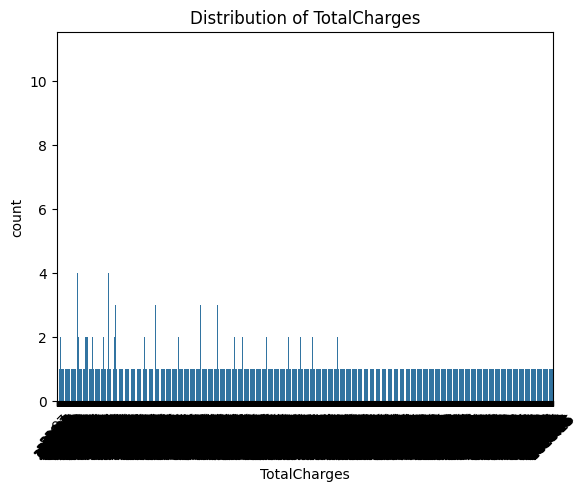

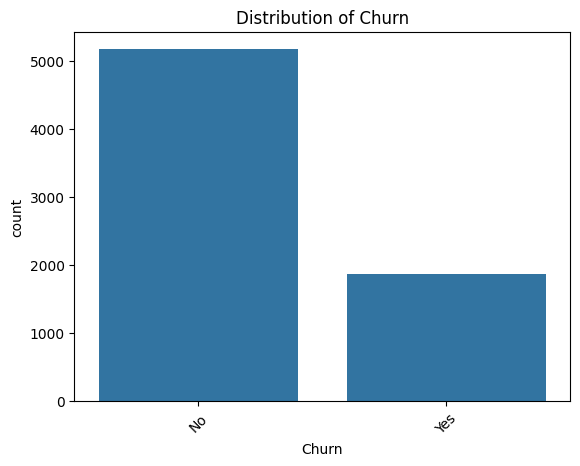

In [135]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in categorical_columns:
    sns.countplot(x=col, data=df)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.show()

In [136]:
df['MultipleLines'].value_counts()

MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

In [137]:
df['PhoneService'].value_counts()

PhoneService
Yes    6361
No      682
Name: count, dtype: int64

In [138]:
df['MultipleLines'] = df['MultipleLines'].replace('No phone service', 'No')
print(df['MultipleLines'].value_counts())

MultipleLines
No     4072
Yes    2971
Name: count, dtype: int64


In [139]:
import numpy as np

conditions = [
    df['PhoneService'] == 'No', 
    (df['PhoneService'] == 'Yes') & (df['MultipleLines'] == 'No'),
    (df['PhoneService'] == 'Yes') & (df['MultipleLines'] == 'Yes')
]

choices = ['No Phone Service', 'Single Line', 'Multiple Lines']

df['PhoneLineStatus'] = np.select(conditions, choices, default='Unknown')

print(df['PhoneLineStatus'].value_counts())

PhoneLineStatus
Single Line         3390
Multiple Lines      2971
No Phone Service     682
Name: count, dtype: int64


In [140]:
df.drop(columns=["PhoneService", "MultipleLines"], inplace=True)

In [141]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges',
       'Churn', 'PhoneLineStatus'],
      dtype='str')

In [142]:
import numpy as np
import pandas as pd

internet_dependent_cols = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

for col in internet_dependent_cols:
    df[col] = df[col].replace('No internet service', 'No')

df['HasInternet'] = np.where(df['InternetService'] == 'No', 'No Internet', 'Has Internet')

print(df['HasInternet'].value_counts())
print(df[internet_dependent_cols].apply(pd.Series.value_counts))

HasInternet
Has Internet    5517
No Internet     1526
Name: count, dtype: int64
     OnlineSecurity  OnlineBackup  DeviceProtection  TechSupport  StreamingTV  \
No             5024          4614              4621         4999         4336   
Yes            2019          2429              2422         2044         2707   

     StreamingMovies  
No              4311  
Yes             2732  


In [143]:
categorical_columns = df.select_dtypes(include=['object']).columns

/tmp/ipykernel_123510/110778351.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include=['object']).columns


In [144]:
import numpy as np
import pandas as pd

imbalance_threshold = 3.0 

for col in categorical_columns:
    if col != "TotalCharges":
        print(f"\n{'='*50}")
        print(f"Column: '{col}'")
        print(f"Unique values: {df[col].nunique()}")
        
        value_counts = df[col].value_counts()
        total = len(df)
        
        print(f"\nDistribution:")
        for val, count in value_counts.items():
            pct = (count / total) * 100
            print(f"  {val:25} : {count:5} ({pct:5.2f}%)")
        
        if len(value_counts) >= 2:
            majority = value_counts.iloc[0]
            minority = value_counts.iloc[-1]
            imbalance_ratio = majority / minority
            majority_pct = (majority / total) * 100
            
            print(f"\nMetrics:")
            print(f"  Imbalance Ratio (Majority/Minority): {imbalance_ratio:.2f}:1")
            print(f"  Majority Class Percentage: {majority_pct:.2f}%")
            
            if imbalance_ratio > imbalance_threshold or majority_pct > 70:
                print(f"  ⚠️  WARNING: Imbalanced feature detected!")
            else:
                print(f"  ✅ Balanced")



Column: 'gender'
Unique values: 2

Distribution:
  Male                      :  3555 (50.48%)
  Female                    :  3488 (49.52%)

Metrics:
  Imbalance Ratio (Majority/Minority): 1.02:1
  Majority Class Percentage: 50.48%
  ✅ Balanced

Column: 'Partner'
Unique values: 2

Distribution:
  No                        :  3641 (51.70%)
  Yes                       :  3402 (48.30%)

Metrics:
  Imbalance Ratio (Majority/Minority): 1.07:1
  Majority Class Percentage: 51.70%
  ✅ Balanced

Column: 'Dependents'
Unique values: 2

Distribution:
  No                        :  4933 (70.04%)
  Yes                       :  2110 (29.96%)

Metrics:
  Imbalance Ratio (Majority/Minority): 2.34:1
  Majority Class Percentage: 70.04%
  ⚠️  WARNING: Imbalanced feature detected!

Column: 'InternetService'
Unique values: 3

Distribution:
  Fiber optic               :  3096 (43.96%)
  DSL                       :  2421 (34.37%)
  No                        :  1526 (21.67%)

Metrics:
  Imbalance Ratio (Majori

In [145]:
imbalance_threshold = 3.0
majority_pct_threshold = 70.0
imbalanced_cols = []

for col in categorical_columns:
    if col not in ["TotalCharges", "Churn"]: 
        value_counts = df[col].value_counts()
        total = len(df)
        
        if len(value_counts) >= 2:
            majority = value_counts.iloc[0]
            minority = value_counts.iloc[-1]
            imbalance_ratio = majority / minority
            majority_pct = (majority / total) * 100
            
            if imbalance_ratio > imbalance_threshold or majority_pct > majority_pct_threshold:
                imbalanced_cols.append(col)

print(imbalanced_cols)

['Dependents', 'OnlineSecurity', 'TechSupport', 'PhoneLineStatus', 'HasInternet']


In [146]:
df.isna().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
PhoneLineStatus     0
HasInternet         0
dtype: int64

## Perbaiki data trouble 

In [147]:
import numpy as np

def convert_to_number(x):
    try:
        return float(x)
    except:
        return np.nan

In [148]:
df['TotalCharges'].isnull().sum()

np.int64(0)

In [149]:
df["TotalCharges"] = df["TotalCharges"].apply(convert_to_number)

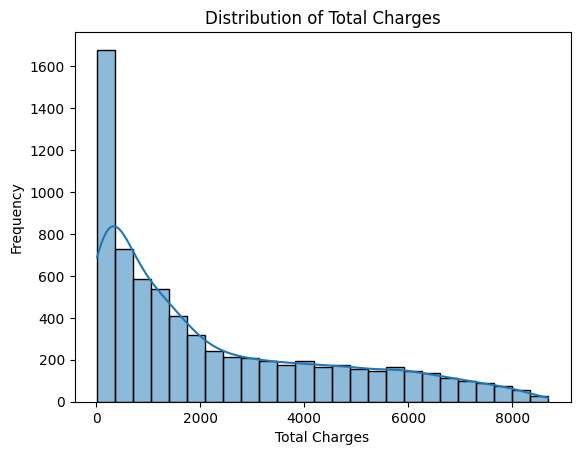

In [150]:
sns.histplot(df['TotalCharges'], kde=True)
plt.title('Distribution of Total Charges')
plt.xlabel('Total Charges')
plt.ylabel('Frequency')
plt.show()

 data **skewed ke kanan (right-skewed)**, artinya banyak nilai kecil dan sedikit nilai besar (outlier). Jadi cara imputasi harus hati-hati supaya distribusi tidak makin bias.

Berikut 3 pendekatan imputation:

#### 1. Median Imputation

#### 2. KNN Imputation

#### 3. Log Transform + Imputation

In [151]:
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

object_df = {}

df_median = df.copy()
df_median["TotalCharges"] = df_median["TotalCharges"].fillna(
    df_median["TotalCharges"].median()
)
object_df["median"] = df_median

df_knn = df.copy()
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
imputer = KNNImputer(n_neighbors=5)
df_knn[num_cols] = imputer.fit_transform(df_knn[num_cols])
object_df["knn"] = df_knn

df_transform = df.copy()
df_transform["TotalCharges_log"] = np.log1p(df_transform["TotalCharges"])
df_transform["TotalCharges_log"] = df_transform["TotalCharges_log"].fillna(
    df_transform["TotalCharges_log"].median()
)
df_transform["TotalCharges"] = np.expm1(df_transform["TotalCharges_log"])
df_transform.drop(columns=["TotalCharges_log"], inplace=True)
object_df["log_transform"] = df_transform

df_logic = df.copy()
df_logic.loc[df_logic["tenure"] == 0, "TotalCharges"] = 0
df_logic["TotalCharges"] = df_logic["TotalCharges"].fillna(
    df_logic["TotalCharges"].median()
)
object_df["business_logic"] = df_logic

for name, data in object_df.items():
    print(f"{name} -> missing:", data["TotalCharges"].isnull().sum())

for name, data in object_df.items():
    print(f"{name} -> skew:", data["TotalCharges"].skew())

median -> missing: 0
knn -> missing: 0
log_transform -> missing: 0
business_logic -> missing: 0
median -> skew: 0.9637890936414893
knn -> skew: 0.9633192098954656
log_transform -> skew: 0.9637890936521661
business_logic -> skew: 0.963234654832277


Hasilnya nunjukin semua metode berhasil mengatasi missing value (0 missing), tapi efeknya ke distribusi ternyata sangat kecil karena nilai skewness semuanya masih di sekitar 0.963. Artinya, meskipun pendekatan imputasi berbeda, bentuk distribusi TotalCharges tetap cenderung right-skewed dan tidak banyak berubah. Dari hasil ini, business logic menghasilkan skewness paling rendah (0.9632), disusul KNN, sehingga sedikit lebih baik dalam menjaga distribusi data, sementara median dan log transform hampir identik. Ini mengindikasikan bahwa missing value pada dataset kemungkinan tidak cukup banyak untuk memberikan dampak signifikan terhadap distribusi keseluruhan, sehingga pemilihan metode sebaiknya lebih difokuskan pada pengaruhnya terhadap performa model dibanding hanya melihat skewness.

In [152]:
df = object_df['business_logic']

## Ubah categorial data menjadi numerical data dan handle imbalancednya pakai smote

In [153]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(df['TotalCharges'].median())

cols_to_process = [c for c in categorical_columns if c not in ['TotalCharges', 'Churn']]

binary_cols = [c for c in cols_to_process if df[c].nunique() == 2]
multi_cols = [c for c in cols_to_process if df[c].nunique() > 2]

le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

df = pd.get_dummies(df, columns=multi_cols, prefix=multi_cols)

X = df.drop('Churn', axis=1)
y = df['Churn']

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

df = pd.concat([X_resampled, y_resampled], axis=1)

In [154]:
df_resampled.dtypes

gender                                       int64
SeniorCitizen                                int64
Partner                                      int64
Dependents                                   int64
tenure                                       int64
OnlineSecurity                               int64
OnlineBackup                                 int64
DeviceProtection                             int64
TechSupport                                  int64
StreamingTV                                  int64
StreamingMovies                              int64
PaperlessBilling                             int64
MonthlyCharges                             float64
TotalCharges                               float64
HasInternet                                  int64
InternetService_DSL                           bool
InternetService_Fiber optic                   bool
InternetService_No                            bool
Contract_Month-to-month                       bool
Contract_One year              

In [155]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

## PCA

In [157]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd

y = df['Churn']
X = df.drop('Churn', axis=1)

df_no_pca = X.copy()
df_no_pca['Churn'] = y.values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)
n_components = (pca_full.explained_variance_ratio_.cumsum() >= 0.95).argmax() + 1

pca = PCA(n_components=n_components, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(n_components)])
df_pca['Churn'] = y.values

print(f"df_no_pca shape: {df_no_pca.shape}")
print(f"df_pca shape: {df_pca.shape}")

df_no_pca shape: (10348, 29)
df_pca shape: (10348, 20)


# Bangun model

In [159]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

X_np = df_no_pca.drop('Churn', axis=1)
y_np = df_no_pca['Churn']
X_p = df_pca.drop('Churn', axis=1)
y_p = df_pca['Churn']

X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(X_np, y_np, test_size=0.2, stratify=y_np, random_state=42)
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(X_p, y_p, test_size=0.2, stratify=y_p, random_state=42)

scaler = StandardScaler()
X_train_np_s = scaler.fit_transform(X_train_np)
X_test_np_s = scaler.transform(X_test_np)

models = {
    'SVM_NoPCA': (SVC(kernel='rbf', probability=True, random_state=42), X_train_np_s, y_train_np, X_test_np_s, y_test_np),
    'SVM_PCA': (SVC(kernel='rbf', probability=True, random_state=42), X_train_p, y_train_p, X_test_p, y_test_p),
    'GBC_NoPCA': (GradientBoostingClassifier(random_state=42), X_train_np, y_train_np, X_test_np, y_test_np),
    'GBC_PCA': (GradientBoostingClassifier(random_state=42), X_train_p, y_train_p, X_test_p, y_test_p),
    'XGB_NoPCA': (xgb.XGBClassifier(random_state=42, eval_metric='logloss'), X_train_np, y_train_np, X_test_np, y_test_np),
    'XGB_PCA': (xgb.XGBClassifier(random_state=42, eval_metric='logloss'), X_train_p, y_train_p, X_test_p, y_test_p)
}

results = {}
for name, (model, X_tr, y_tr, X_te, y_te) in models.items():
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]
    results[name] = {
        'Accuracy': accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred),
        'Recall': recall_score(y_te, y_pred),
        'F1-Score': f1_score(y_te, y_pred),
        'ROC-AUC': roc_auc_score(y_te, y_prob)
    }

comparison_df = pd.DataFrame(results).T
print(comparison_df.round(4))

           Accuracy  Precision  Recall  F1-Score  ROC-AUC
SVM_NoPCA    0.8454     0.8488  0.8406    0.8447   0.9244
SVM_PCA      0.8348     0.8354  0.8338    0.8346   0.9153
GBC_NoPCA    0.8498     0.8390  0.8657    0.8521   0.9323
GBC_PCA      0.8208     0.8103  0.8377    0.8238   0.9070
XGB_NoPCA    0.8493     0.8479  0.8512    0.8496   0.9308
XGB_PCA      0.8304     0.8320  0.8280    0.8300   0.9137


In [160]:
import pandas as pd
import numpy as np
import xgboost as xgb
import joblib
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, roc_auc_score, f1_score, precision_score, recall_score

X = df_no_pca.drop('Churn', axis=1)
y = df_no_pca['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

xgb_clf = xgb.XGBClassifier(
    scale_pos_weight=pos_weight,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

param_distributions = {
    'n_estimators': [150, 200, 300, 400],
    'max_depth': [3, 4, 5, 6, 7],
    'learning_rate': [0.01, 0.05, 0.1, 0.15],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.2, 0.3],
    'min_child_weight': [1, 3, 5, 7]
}

random_search = RandomizedSearchCV(
    estimator=xgb_clf,
    param_distributions=param_distributions,
    n_iter=40,
    scoring='f1',
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("🔍 Mencari hyperparameter terbaik dengan RandomizedSearchCV + 5-Fold CV...")
random_search.fit(X_train, y_train)

best_model = random_search.best_estimator_
print(f"✅ Best Params: {random_search.best_params_}")
print(f"✅ Best CV F1-Score: {random_search.best_score_:.4f}\n")

y_probs = best_model.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.30, 0.70, 0.01)
best_f1, optimal_thresh = 0, 0.5

for t in thresholds:
    y_pred_t = (y_probs >= t).astype(int)
    f1 = f1_score(y_test, y_pred_t)
    if f1 > best_f1:
        best_f1 = f1
        optimal_thresh = t

print(f"🎯 Threshold Optimal (Max F1): {optimal_thresh:.2f}")
print("   📌 Threshold < 0.5 → Lebih agresif tangkap 'Yes' (Recall ↑, Precision ↓)")
print("   📌 Threshold > 0.5 → Lebih ketat prediksi 'Yes' (Precision ↑, Recall ↓)")

y_pred_final = (y_probs >= optimal_thresh).astype(int)

print("\n📊 Final Metrics pada Test Set:")
print(classification_report(y_test, y_pred_final, target_names=['No (0)', 'Yes (1)']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_probs):.4f}")

MODEL_PATH = 'xgb_churn_model.pkl'
THRESH_PATH = 'xgb_churn_threshold.pkl'

joblib.dump(best_model, MODEL_PATH)
joblib.dump(optimal_thresh, THRESH_PATH)

print(f"\n💾 Model tersimpan: {MODEL_PATH}")
print(f"💾 Threshold tersimpan: {THRESH_PATH}")
print("✅ Pipeline selesai. Siap untuk production inference!")

🔍 Mencari hyperparameter terbaik dengan RandomizedSearchCV + 5-Fold CV...
Fitting 5 folds for each of 40 candidates, totalling 200 fits
✅ Best Params: {'subsample': 0.9, 'n_estimators': 400, 'min_child_weight': 1, 'max_depth': 7, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 0.8}
✅ Best CV F1-Score: 0.8549

🎯 Threshold Optimal (Max F1): 0.38
   📌 Threshold < 0.5 → Lebih agresif tangkap 'Yes' (Recall ↑, Precision ↓)
   📌 Threshold > 0.5 → Lebih ketat prediksi 'Yes' (Precision ↑, Recall ↓)

📊 Final Metrics pada Test Set:
              precision    recall  f1-score   support

      No (0)       0.90      0.77      0.83      1035
     Yes (1)       0.80      0.91      0.85      1035

    accuracy                           0.84      2070
   macro avg       0.85      0.84      0.84      2070
weighted avg       0.85      0.84      0.84      2070

ROC-AUC Score: 0.9332

💾 Model tersimpan: xgb_churn_model.pkl
💾 Threshold tersimpan: xgb_churn_threshold.pkl
✅ Pipeline selesai. Siap untuk

In [161]:
import os
import joblib

save_dir = os.path.dirname(os.path.abspath('__file__')) 
# atau manual: save_dir = '/home/misbahul/code/ai/machine-learning/task'

model_path = os.path.join(save_dir, 'xgb_churn_model.pkl')
thresh_path = os.path.join(save_dir, 'xgb_churn_threshold.pkl')

joblib.dump(best_model, model_path)
joblib.dump(optimal_thresh, thresh_path)

print(f"Saved to: {model_path}")

Saved to: /home/misbahul/code/ai/machine-learning/task/tasks/xgb_churn_model.pkl
